In [1]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import torch
import sys
from tqdm import tqdm

In [2]:
def forward(x_0, t):
    """
    Computes the state x_t of the Ornstein-Uhlenbeck process at any time t.
    This is the closed-form solution to Equation (1): dx = -x dt + sqrt(2) dB.
    """
    epsilon = torch.randn_like(x_0) # N(0,1)
    x_t = x_0*np.exp(-t) + np.sqrt(1-np.exp(-2*t))*epsilon
    return x_t, epsilon

def backward(x_t, t, dt, mu_star, std, epsilon=None):
    """
    Moves the Ornstein-Uhlenbeck (OU) process one step backward in time (t -> t-dt).
    This implements the discrete version of:
    -dy_i(t) = [y_i + 2 * Score_i] dt + sqrt(2) * dB_t
    Which is discretize as:
    x_{t-dt} = x_t + [x_t + 2 * Score(x_t, t)] * dt + sqrt(2 * dt) * epsilon
    """
    if epsilon == None:                                # For reproducibility
        epsilon = torch.randn_like(x_t)                # N(0,1)
    f = -x_t - 2*score(x_t, t, mu_star, std)           # Drift term
    dW_t = np.sqrt(2*dt)*epsilon                       # N(0, dt)
    x_tm1 = x_t - dt*f + dW_t
    return x_tm1, epsilon

def score(x_t, t, mu_star, std):
    """
    Score function of a 2D - 2modes multivariate Gaussian
    x_t (torch.Tensor): Current particle positions. Shape (batch_size, d).
    t (float): Current diffusion time.
    mu_star (torch.Tensor): symmetric stationary mean. Shape (d,).
    std (float): The initial standard deviation (blur) of the species clusters.
    """
    ns = x_t.shape[1]
    delta_t = 1 - np.exp(-2*t)
    Gamma_t = delta_t + std**2*np.exp(-2*t)
    mu_t = mu_star * np.exp(-t)
    m = torch.matmul(mu_t, x_t)
    mu_t = mu_t.repeat(ns).reshape(-1, ns)
    return torch.tanh(m/Gamma_t)*mu_t/Gamma_t - x_t/Gamma_t

def classify(x, mu_star):
    """
    Predicts which of the two classes of the MV Gaussian a particle belongs to.
    It projects the particle onto the axis defined by the class centers.
    """
    m = np.dot(mu_star, x)
    return np.sign(m)

In [3]:
def plot_data_distribution(step_idx, title, ax, path_history, times, is_final=False):
    t = times[step_idx]
    d1_samples = path_history[step_idx, :, 0] 
    d2_samples = path_history[step_idx, :, 1] 
    
    # 2. Calculate Analytical Density for the heatmap
    limit = 6
    res = 100
    _x = np.linspace(-limit, limit, res)
    _y = np.linspace(-limit, limit, res)
    xx, yy = np.meshgrid(_x, _y)
    
    # OU parameters at time t
    gamma_t = (1 - np.exp(-2*t)) + (std**2 * np.exp(-2*t))
    mu_t = mu_star.numpy() * np.exp(-t)
    
    # GMM Density: p_t(x) = 0.5 * [N(mu_t, gamma) + N(-mu_t, gamma)]
    d1 = (xx - mu_t[0])**2 + (yy - mu_t[1])**2
    d2 = (xx + mu_t[0])**2 + (yy + mu_t[1])**2
    density = (np.exp(-0.5 * d1 / gamma_t) + np.exp(-0.5 * d2 / gamma_t)) / (2 * np.pi * gamma_t)

    # 3. Plotting
    ax.contourf(xx, yy, density, levels=20, cmap="Reds", alpha=0.5)
    ax.scatter(d1_samples, d2_samples, s=80, color='black', marker='X', label='Data')
        
    ax.set_title(title, fontsize=14)
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.set_aspect('equal')
    ax.grid(alpha=0.1)

In [4]:
def plot_speciation_3d(path_history, times, mu_star, std, nsamples, seed = 123):
    """
    Visualizes the 2D speciation process over time in a 3D plot.
    """
    torch.manual_seed(seed)
    T_max = times[0]
    plane_limit = 6
    res = 50 # Resolution for the density planes
    
    fig = plt.figure(figsize=(15, 20))
    ax = fig.add_subplot(111, projection='3d')

    ax.set_ylabel("Diffusion Time (t)", fontsize=14, labelpad=20)
    ax.set_xlabel("$x_1$", fontsize=10)
    ax.set_zlabel("$x_2$", fontsize=10)
    ax.set_ylim(0, T_max)
    
    ax.invert_yaxis() # Invert Y so time flows downward from T_max to 0
    ax.set_box_aspect((1, 3, 1)) # Stretch the time axis
    ax.view_init(elev=30, azim=-120)

    # Create the grid for the density maps (t = T)
    _grid = np.linspace(-plane_limit, plane_limit, res) 
    xx, zz = np.meshgrid(_grid, _grid)
    
    # Single Gaussian density at T (Normalizing by 1 + std^2)
    density_T = np.exp(-0.5 * (xx**2 + zz**2) / (1 + std**2))
    ax.contourf(xx, density_T, zz, zdir='y', offset=T_max, cmap='Blues', alpha=0.3)
    
    # Scatter plot of the 6 noisy starting points
    x1_start = path_history[0, :, 0]
    x2_start = path_history[0, :, 1]
    ax.scatter(x2_start, np.full_like(x2_start, T_max), x1_start, 
               s=100, color='grey', alpha=0.6, label="Ancestral Noise")

    # The Trajectories
    for i in range(nsamples):
        x1_path = path_history[:, i, 0]
        x2_path = path_history[:, i, 1]
        final_pos = torch.tensor(path_history[-1, i, :])
        class_val = classify(final_pos, mu_star)
        class_color = 'gold' if class_val > 0 else 'royalblue'
        ax.plot(x2_path, times, x1_path, color=class_color, lw=2, alpha=0.8)

    # Bimodal Gaussian Mixture density (t = 0)
    dist1 = (zz - mu_star[0].item())**2 + (xx - mu_star[1].item())**2
    dist2 = (zz + mu_star[0].item())**2 + (xx + mu_star[1].item())**2
    density_0 = np.exp(-0.5 * dist1 / std**2) + np.exp(-0.5 * dist2 / std**2)
    
    ax.contourf(xx, density_0, zz, zdir='y', offset=0, cmap='Reds', alpha=0.3)
    x1_final = path_history[-1, :, 0]
    x2_final = path_history[-1, :, 1]
    ax.scatter(x2_final, np.zeros_like(x2_final), x1_final, 
               s=150, color='black', marker='X', edgecolors='white', linewidth=1)

    ax.set_xticks([])
    ax.set_zticks([])
    plt.tight_layout()
    plt.show()


### Toy example

In [5]:
torch.manual_seed(123)
d = 2             # Dimension is fixed to 2
nsamples = 6     # Number of trajectories
T_max = 10.0
dt = 0.01
times = np.arange(T_max, 0, -dt)

# Define our targets in 2D space: +/- (mu_star, mu_star)
mu_star = torch.tensor([4.0, 4.0])
std = 1.0

# Start with pure random noise at t=T 
# We initialize as (Dimensions, Samples) to match your score() logic
x_current = torch.randn(d, nsamples) 

path_history = []

# Simulation Loop
for t in tqdm(times):
    path_history.append(x_current.T.clone().numpy()) 
    x_current, _ = backward(x_current, t, dt, mu_star, std)

path_history = np.array(path_history)

100%|████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 17803.33it/s]


In [6]:
t = times[1]
d1_samples = path_history[1, :, 0] 
d2_samples = path_history[1, :, 1] 

# 2. Calculate Analytical Density for the heatmap
limit = 6
res = 100
_x = np.linspace(-limit, limit, res)
_y = np.linspace(-limit, limit, res)
xx, yy = np.meshgrid(_x, _y)

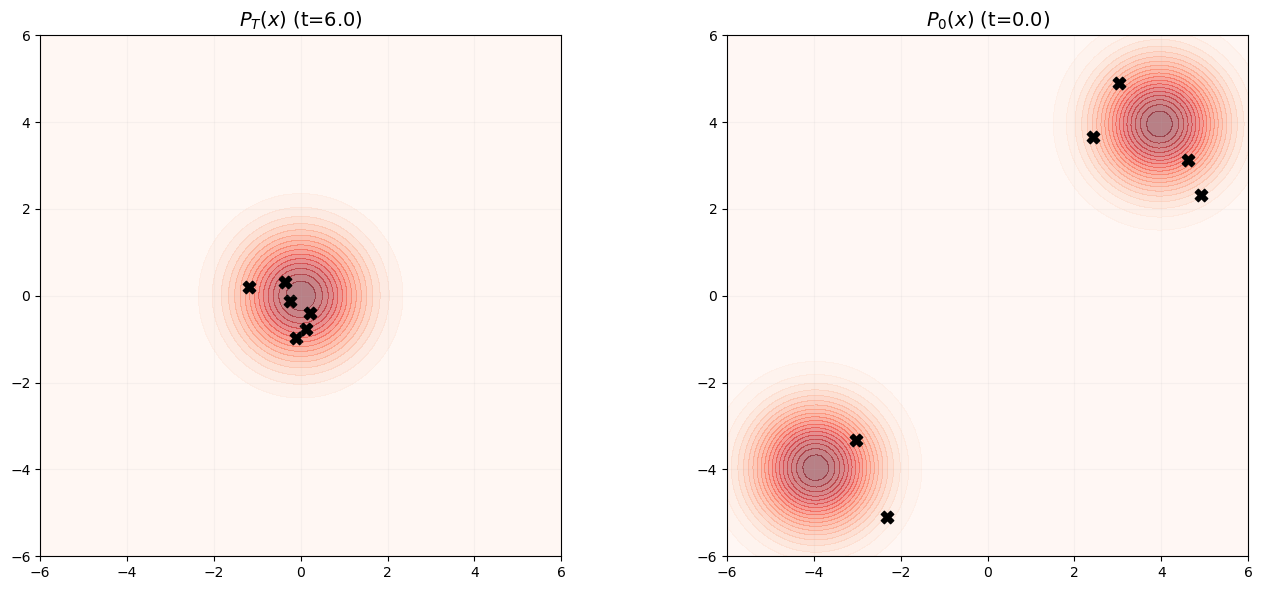

In [7]:
# --- Execute Plotting Side-by-Side ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# P_T (Start of reverse process - Pure Noise)
plot_data_distribution(0, "$P_T(x)$ (t=6.0)", ax1, path_history, times, is_final=True)

# P_0 (End of reverse process - Clean Data)
plot_data_distribution(-1, "$P_0(x)$ (t=0.0)", ax2, path_history, times, is_final=True)

plt.tight_layout()
plt.show()

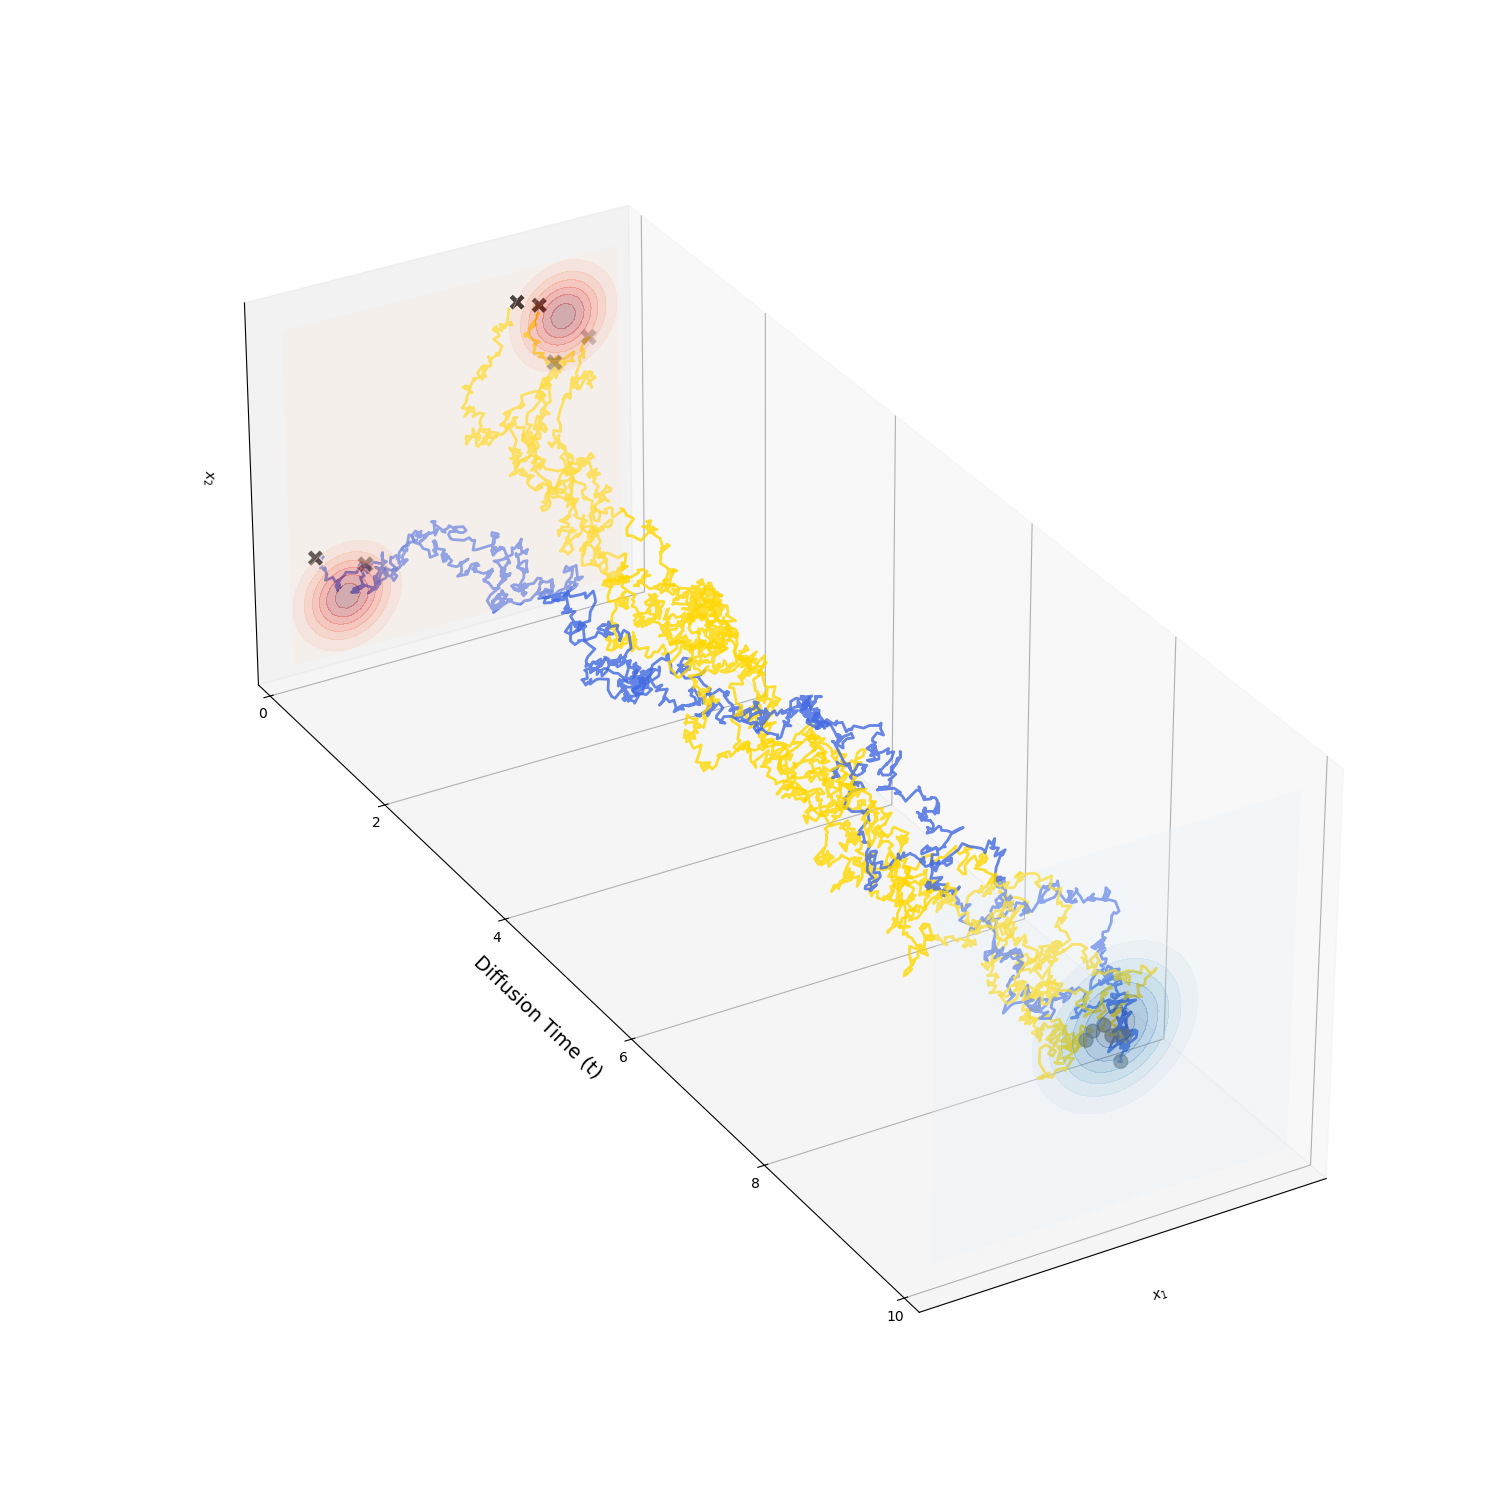

In [8]:
plot_speciation_3d(path_history, times, mu_star, std, nsamples)